In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv("data/online_retail.csv", encoding='latin1')

# Show first 5 rows
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
data.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
data = data.dropna(subset=['CustomerID'])


In [5]:
data = data[data['Quantity'] > 0]


In [6]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])


In [7]:
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']


In [8]:
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
data.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


In [10]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

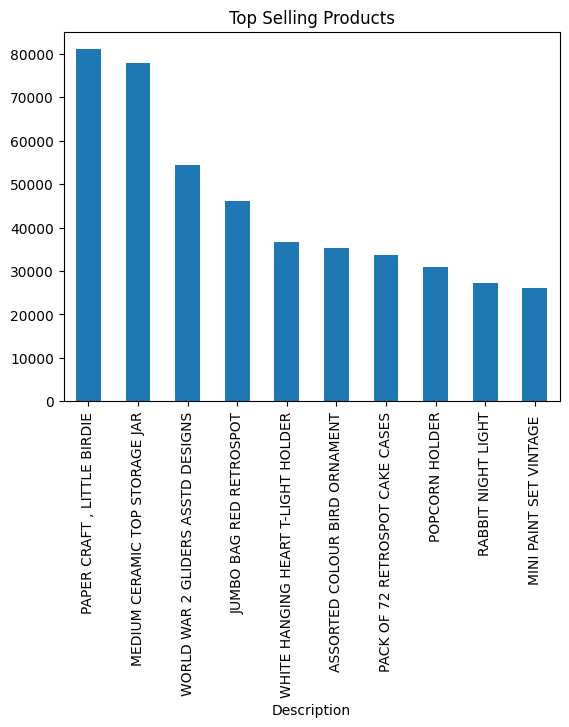

In [11]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.show()


In [12]:
data['Date'] = data['InvoiceDate'].dt.date


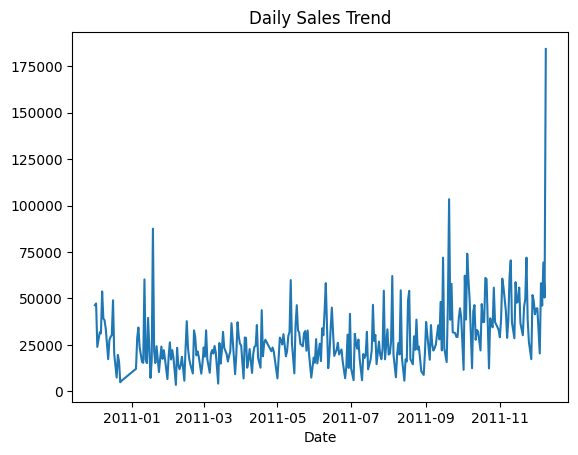

In [13]:
daily_sales = data.groupby('Date')['TotalPrice'].sum()

daily_sales.plot()
plt.title("Daily Sales Trend")
plt.show()


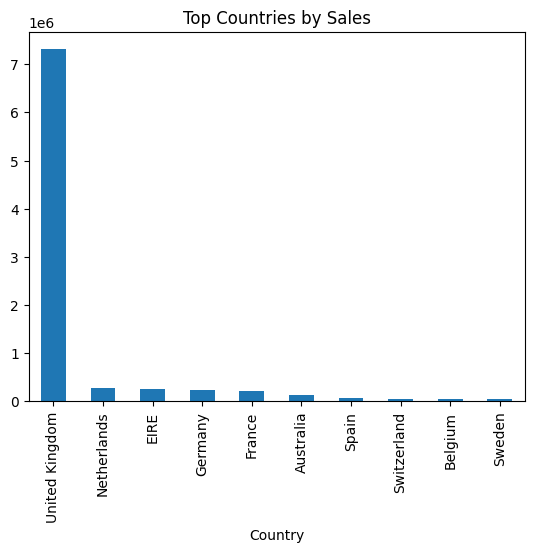

In [14]:
top_countries = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')
plt.title("Top Countries by Sales")
plt.show()


In [15]:
data['Month'] = data['InvoiceDate'].dt.month


In [16]:
X = data[['Month']]
y = data['TotalPrice']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
predictions = model.predict(X_test)


In [20]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)


Mean Squared Error: 5124.343598994659


In [21]:
customer_data = data.groupby('CustomerID').agg({
    'TotalPrice': 'sum',
    'Quantity': 'sum'
}).reset_index()

customer_data.head()


,CustomerID,TotalPrice,Quantity
0,12346.0,77183.60,74215
1,12347.0,4310.00,2458
2,12348.0,1797.24,2341
3,12349.0,1757.55,631
4,12350.0,334.40,197


In [22]:
X = customer_data[['TotalPrice', 'Quantity']]


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(X_scaled)


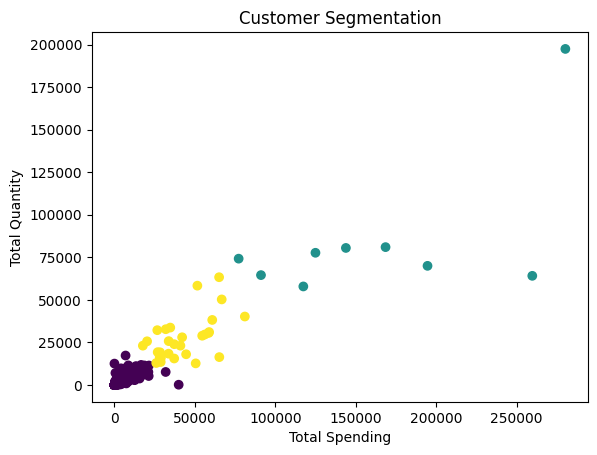

In [25]:
import matplotlib.pyplot as plt

plt.scatter(customer_data['TotalPrice'], customer_data['Quantity'], c=customer_data['Cluster'])
plt.xlabel("Total Spending")
plt.ylabel("Total Quantity")
plt.title("Customer Segmentation")
plt.show()


In [26]:
product_matrix = pd.pivot_table(
    data,
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(product_matrix.T)


In [28]:
similarity_df = pd.DataFrame(
    similarity,
    index=product_matrix.columns,
    columns=product_matrix.columns
)

similarity_df = similarity_df.apply(pd.to_numeric)
print(similarity_df.dtypes.unique())



[dtype('float64')]


In [29]:
def recommend_products(product_name):
    similar_products = similarity_df[product_name].sort_values(ascending=False)
    return similar_products.iloc[1:6]


In [30]:
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")


Description
GIN + TONIC DIET METAL SIGN           0.935872
TEA TIME TEA TOWELS                   0.925193
FAIRY CAKE FLANNEL ASSORTED COLOUR    0.914906
DOORMAT FAIRY CAKE                    0.888525
RED HANGING HEART T-LIGHT HOLDER      0.258613
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [31]:
import os
print(os.getcwd())


/Users/mohitpoonia/Desktop/AI Business Assistant


In [32]:
import pickle

pickle.dump(model, open("models/sales_model.pkl","wb"))
pickle.dump(kmeans, open("models/customer_cluster.pkl","wb"))
pickle.dump(similarity_df, open("models/recommendation.pkl","wb"))


In [33]:
import os
os.listdir("models")


['recommendation.pkl', 'customer_cluster.pkl', 'sales_model.pkl']